## Machine Learning ZoomCamp 2026 - Homework 2

In [68]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [69]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
df = pd.read_csv(data)
df.head()


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Preparing the dataset
Use only the following columns:

* 'engine_displacement',
* 'horsepower',
* 'vehicle_weight',
* 'model_year',
* 'fuel_efficiency_mpg'

In [70]:
list(df.columns)

['model_year',
 'origin',
 'fuel_type',
 'drivetrain',
 'num_doors',
 'engine_displacement',
 'num_cylinders',
 'horsepower',
 'vehicle_weight',
 'acceleration',
 'fuel_efficiency_mpg']

In [71]:
df1 = df.copy()
df1 = df1[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df1.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA
* Look at the fuel_efficiency_mpg variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

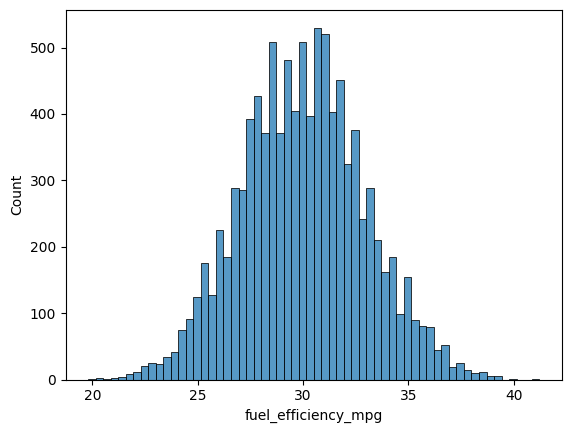

In [72]:
sns.histplot(df1['fuel_efficiency_mpg'])

### Question 1
There's one column with missing values. What is it?

In [73]:
df1.isnull().sum()

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


### Question 2
What's the median (50% percentile) for variable 'horsepower'?

In [74]:
df1['horsepower'].median()

254.0

### Prepare and split the dataset
Shuffle the filtered dataset and create the split exactly as in the lecture:

```
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed 9.

In [75]:
n = len(df1)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df1.iloc[idx[:n_train]]
df_val = df1.iloc[idx[n_train:n_train + n_val]]
df_test = df1.iloc[idx[n_train + n_val:]]


In [76]:
len(df_train), len(df_val), len(df_test)


(6000, 2000, 2000)

In [77]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [78]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [79]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

### Question 3
* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
* Which option gives better RMSE?

In [80]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

#### Option 1: Filling missing values with zero

In [81]:
def prepare_X(df):
    df_num = df
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
y_pred_train = w0 + X_train.dot(w)
print(f"RMSE train: {round(rmse(y_train, y_pred_train), 3)}")

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val.dot(w)
print(f"RMSE val: {round(rmse(y_val, y_pred_val), 3)}")

RMSE train: 2.2
RMSE val: 2.205


#### Option 2: Filling missing values with the mean

In [82]:
def prepare_X_mean(df):
  df_num = df
  mean_hp = df_num['horsepower'].mean()
  df_num['horsepower'] = df_num['horsepower'].fillna(mean_hp)
  X = df_num.values
  return X

X_train = prepare_X_mean(df_train)
w0, w = train_linear_regression(X_train, y_train)
y_pred_train = w0 + X_train.dot(w)
print(f"RMSE train: {rmse(y_train, y_pred_train).round(3)}")

X_val = prepare_X_mean(df_val)
y_pred_val = w0 + X_val.dot(w)
print(f"RMSE val: {rmse(y_val, y_pred_val).round(3)}")

RMSE train: 2.198
RMSE val: 2.202


### Question 4
* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
* Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.

In [83]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)

    print(r, score)

0 2.2018
0.01 2.2018
0.1 2.2156
1 2.3442
5 2.4146
10 2.4268
100 2.4387


### Question 5
* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
* Round the result to 3 decimal digits (round(std, 3))

Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.

In [86]:
def prepare_X(df):
    df_num = df
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

total_seed = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df1)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed=seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df1.iloc[idx[:n_train]]
    df_val = df1.iloc[idx[n_train:n_train + n_val]]
    df_test = df1.iloc[idx[n_train + n_val:]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val)
    y_pred_val = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred_val)
    print(f"Seed: {seed}, RMSE val: {score}")
    total_seed.append(score)


Seed: 0, RMSE val: 2.239204143046126
Seed: 1, RMSE val: 2.2021128210838845
Seed: 2, RMSE val: 2.1634197787530947
Seed: 3, RMSE val: 2.2043588768539224
Seed: 4, RMSE val: 2.2018800943311554
Seed: 5, RMSE val: 2.2457851509085134
Seed: 6, RMSE val: 2.2697212079524043
Seed: 7, RMSE val: 2.190794599933443
Seed: 8, RMSE val: 2.216611201686444
Seed: 9, RMSE val: 2.2070365928178957


In [87]:
round(np.std(total_seed), 3)


np.float64(0.029)

> Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.

### Question 6
* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with r=0.001.
* What's the RMSE on the test dataset?

In [89]:
def prepare_X(df):
    df_num = df
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


n = len(df1)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df1.iloc[idx[:n_train]]
df_test = df1.iloc[idx[n_train:]]

y_train = df_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_test = prepare_X(df_test)
y_pred_test = w0 + X_test.dot(w)
score = rmse(y_test, y_pred_test)
print(f"RMSE test: {round(score, 3)}")



RMSE test: 2.236
